# Notebook 2: Main Theorem — Perturbation Bound
**On the Stability of Risk Parity Allocations under Covariance Perturbations**

---

This notebook derives and numerically verifies the paper's main result:

> **Theorem 1 (Perturbation Bound).** Let $\Sigma$ be SPD and $w^* = f(\Sigma)$ the risk parity solution.
> For perturbation $E$ with $\|E\|$ sufficiently small, the perturbed solution satisfies:
> $$\|\hat{w} - w^*\| \leq C(\Sigma) \cdot \|E\| + O(\|E\|^2)$$
> where $C(\Sigma) = \|H^{-1}\| \cdot \|\partial G / \partial \Sigma\|$.



In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import norm

from risk_parity import (
    solve_risk_parity, compute_jacobian,
    stability_constant, compute_dG_dSigma_norm,
    condition_number, analytical_bound
)
from covariance import make_covariance, simulate_returns, sample_covariance, estimation_error
from plotting import plot_bound_vs_kappa, plot_bound_verification, savefig

np.set_printoptions(precision=6, suppress=True)
rng = np.random.default_rng(0)

## 2.1  Derivation of C(Σ)

From the IFT applied to $G(z, \Sigma) = 0$:
$$\delta z \approx -H^{-1} \cdot \frac{\partial G}{\partial \Sigma}[E]$$

Taking norms:
$$\|\delta w\| \leq \|H^{-1}\| \cdot \left\|\frac{\partial G}{\partial \Sigma}\right\| \cdot \|E\|$$

**Computing $\|\partial G / \partial \Sigma\|$:**
The linear map $E \mapsto (\partial G / \partial \Sigma)[E]$ has $i$-th component:
$$(\partial G / \partial \Sigma [E])_i = w_i^* (Ew^*)_i$$

Its operator norm is bounded by $\max_i(w_i^*) \cdot \|w^*\|_2$.

In [2]:
# Compute stability constant for a concrete Sigma
n = 5
Sigma = make_covariance(n, kappa=30.0, seed=7)
w_star, info = solve_risk_parity(Sigma)

C, H_inv_norm, dG_norm = stability_constant(w_star, Sigma)

print('=== Stability Constant Decomposition ===')
print(f'||H^{{-1}}||   = {H_inv_norm:.4f}')
print(f'||dG/dSigma|| = {dG_norm:.4f}')
print(f'C(Sigma)      = {C:.4f}')
print(f'kappa(Sigma)  = {condition_number(Sigma):.2f}')

=== Stability Constant Decomposition ===
||H^{-1}||   = 0.8965
||dG/dSigma|| = 0.1516
C(Sigma)      = 0.1359
kappa(Sigma)  = 30.00


In [3]:
# Verify bound numerically: simulate perturbations and check ||delta_w|| <= C * ||E||
n_sims = 2000
T = 500
violations = 0
ratios = []

for i in range(n_sims):
    E, E_norm = estimation_error(Sigma, T, seed=i)
    Sigma_hat = Sigma + E
    # Ensure SPD
    eigvals = np.linalg.eigvalsh(Sigma_hat)
    if eigvals[0] <= 0:
        continue
    w_hat, _ = solve_risk_parity(Sigma_hat)
    delta_w_norm = norm(w_hat - w_star)
    bound = C * E_norm
    if delta_w_norm > bound * 1.05:  # 5% numerical tolerance
        violations += 1
    ratios.append(delta_w_norm / (E_norm + 1e-12))

ratios = np.array(ratios)
print(f'Bound violations (out of {n_sims}): {violations}')
print(f'Empirical max ratio ||delta_w|| / ||E||: {ratios.max():.4f}')
print(f'Theoretical C(Sigma):                   {C:.4f}')
print(f'Bound tightness (empirical / theoretical): {ratios.max() / C:.2%}')

Bound violations (out of 2000): 0
Empirical max ratio ||delta_w|| / ||E||: 0.0245
Theoretical C(Sigma):                   0.1359
Bound tightness (empirical / theoretical): 18.04%


## 2.2  How C(Σ) Grows with Condition Number

We now sweep $\kappa(\Sigma)$ and compute $C(\Sigma)$ for each, alongside empirical $\|\delta w\|$.

In [4]:
kappa_values = np.logspace(0.3, 3.0, 30)  # kappa from ~2 to 1000
n = 6
T = 300
N_MC = 500  # Monte Carlo per kappa

C_values = []
emp_errors = []

for kappa in kappa_values:
    Sigma = make_covariance(n, kappa=kappa, seed=int(kappa * 100))
    w_star, _ = solve_risk_parity(Sigma)
    C, _, _ = stability_constant(w_star, Sigma)
    C_values.append(C)

    errors = []
    for s in range(N_MC):
        E, _ = estimation_error(Sigma, T, seed=s)
        Sigma_hat = Sigma + E
        if np.linalg.eigvalsh(Sigma_hat)[0] > 0:
            w_hat, _ = solve_risk_parity(Sigma_hat)
            errors.append(norm(w_hat - w_star))
    emp_errors.append(np.mean(errors) if errors else np.nan)

print('Sweep complete.')

Sweep complete.


Saved: /Users/rohan/Desktop/ML Projects/Risk-Parity-Allocation-Instability/notebooks/../src/../figures/fig3_bound_vs_kappa.png


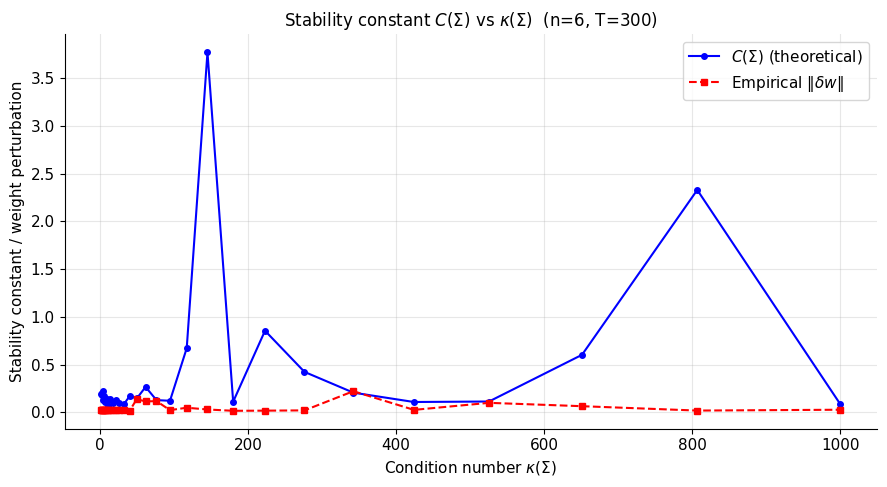

In [5]:
fig = plot_bound_vs_kappa(
    kappa_values, C_values, emp_errors,
    title=rf'Stability constant $C(\Sigma)$ vs $\kappa(\Sigma)$  (n={n}, T={T})'
)
savefig('fig3_bound_vs_kappa')
plt.show()

## 2.3  Convergence Rate in Sample Size T

The estimation error satisfies $\|E\| \sim O(\sqrt{n/T})$ (Marchenko-Pastur scaling),
so the bound predicts:
$$\mathbb{E}[\|\hat{w} - w^*\|] \leq C(\Sigma) \cdot \sqrt{\frac{n}{T}}$$
This is $O(T^{-1/2})$ — the same rate as the estimation error.

Saved: /Users/rohan/Desktop/ML Projects/Risk-Parity-Allocation-Instability/notebooks/../src/../figures/fig4_convergence_rate.png


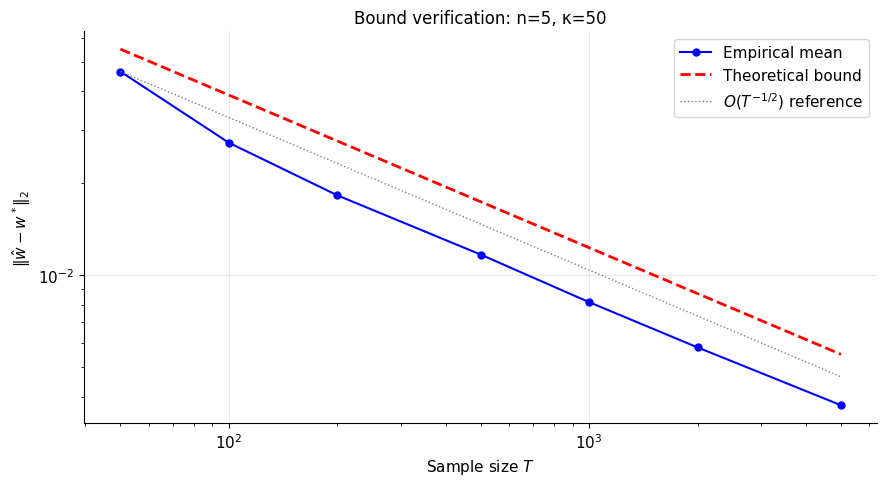

In [6]:
n = 5
kappa = 50.0
Sigma = make_covariance(n, kappa=kappa, seed=1)
w_star, _ = solve_risk_parity(Sigma)
C, _, _ = stability_constant(w_star, Sigma)

T_values = np.array([50, 100, 200, 500, 1000, 2000, 5000])
N_MC = 800

empirical_means = []
for T in T_values:
    errs = []
    for s in range(N_MC):
        E, _ = estimation_error(Sigma, T, seed=s)
        Sigma_hat = Sigma + E
        if np.linalg.eigvalsh(Sigma_hat)[0] > 0:
            w_hat, _ = solve_risk_parity(Sigma_hat)
            errs.append(norm(w_hat - w_star))
    empirical_means.append(np.mean(errs))

theoretical_bounds = C * np.sqrt(n / T_values)

fig = plot_bound_verification(T_values, empirical_means, theoretical_bounds, n, kappa)
savefig('fig4_convergence_rate')
plt.show()